# VAD Downstream 実験ノートブック

## 何をやるか

このノートブックは、**音声から感情を推定するモデル**を学習・評価します。

### パイプライン

```
wav ファイル
   ↓
emotion2vec（エンコーダ）  ← 事前学習済み・重みは固定
   ↓ 768次元 フレームレベル特徴量
AttentionPooling           ← 可変長フレームを1ベクトルに集約
   ↓
VADDecoder（FNN）          ← 学習対象（Stage 1）
   ↓ Valence / Arousal / Dominance の3値（-1〜1）
線形分類器                  ← 学習対象（Stage 2）
   ↓
感情クラス（ang / hap / neu / sad）
```

### 学習の2段階

| Stage | 目的 | 損失関数 | 学習するパラメータ |
|-------|------|----------|--------------------|
| Stage 1 | VAラベルからVAD値を予測する | CCC損失（連続値回帰） | VADDecoder |
| Stage 2 | VAD値を使って感情分類する | CrossEntropy | VADDecoder（微調整） + 線形分類器 |

### 評価方法

IEMOCAP は5セッションに分かれているため、**5-fold Leave-One-Session-Out 交差検証**を行います。
1セッションをテスト、残り4セッションを訓練（8割）・検証（2割）に使います。

---

## 実行順序

1. 環境セットアップ（必要パッケージのインストール）
2. 特徴量抽出（初回のみ：wavファイル → .npy 保存）
3. パス設定・モジュール読み込み
4. データ読み込み・確認
5. モデル構築・動作確認
6. DataLoader 作成
7. Stage 1 学習（VA-CCC）
8. Stage 2 学習（感情分類）
9. テスト評価・結果可視化

## 1. 環境セットアップ

必要なパッケージをインストールします。

- `funasr` : emotion2vec モデルをロード・推論するためのインターフェース（Alibaba 製）
- `soundfile` : wav ファイルの読み込みに使用

## 2. 特徴量抽出（初回のみ実行）

### 何をやるか

IEMOCAP の wav ファイルを1発話ずつ emotion2vec に通し、**フレームレベルの特徴量（768次元）** を抽出して保存します。

### 出力ファイル

| ファイル | 内容 |
|----------|------|
| `iemocap_feats.npy` | 全発話のフレーム特徴量を縦に結合した配列 `(全フレーム数, 768)` |
| `iemocap_feats.lengths` | 1行1発話、その発話のフレーム数（何行目からどの発話かを特定するために使用） |
| `iemocap_feats.emo` | 1行1発話、`発話ID\t感情ラベル` の形式 |

### なぜフレームレベルか

後段の AttentionPooling が、可変長のフレーム列から発話全体を表す1ベクトルを学習によって求めます。  
utterance レベルで平均してしまうと、この学習の余地がなくなります。

---

**すでにファイルが存在する場合は自動的にスキップします。**

In [1]:
import os, sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # OpenMP 二重ロード回避

# ffmpeg が anaconda の Library/bin にあるので PATH に追加する
_ffmpeg_dir = r"C:\Users\RD004\anaconda3\Library\bin"
if _ffmpeg_dir not in os.environ.get("PATH", ""):
    os.environ["PATH"] = _ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")
    print(f"PATH に追加: {_ffmpeg_dir}")

# 環境確認
import torch, torchaudio, soundfile
print(f"torch      : {torch.__version__}")
print(f"torchaudio : {torchaudio.__version__}")
print(f"soundfile  : {soundfile.__version__}")
print(f"CUDA利用可能 : {torch.cuda.is_available()} (CPUモードで実行)")


torch      : 2.12.0+cpu
torchaudio : 2.11.0+cpu
soundfile  : 0.13.1
CUDA利用可能 : False (CPUモードで実行)


In [2]:
# torchaudio 2.9+ は torchcodec を必須とするが未インストール。
# soundfile（インストール済み）で torchaudio.load を上書きして回避する。
import soundfile as sf
import torch
import torchaudio as _torchaudio

def _soundfile_load(uri, frame_offset=0, num_frames=-1, normalize=True,
                    channels_first=True, format=None, buffer_size=4096, backend=None):
    data, sr = sf.read(str(uri), dtype="float32", always_2d=True)
    tensor = torch.from_numpy(data).T
    if frame_offset > 0:
        tensor = tensor[:, frame_offset:]
    if num_frames > 0:
        tensor = tensor[:, :num_frames]
    if not channels_first:
        tensor = tensor.T
    return tensor, sr

_torchaudio.load = _soundfile_load
print("torchaudio.load → soundfile バックエンドにパッチ完了")


torchaudio.load → soundfile バックエンドにパッチ完了


In [3]:
import sys
import importlib
from pathlib import Path
import numpy as np

# 必要パッケージが足りなければインストールして即座に再認識させる
_missing = []
for pkg, import_name in [("funasr", "funasr"), ("soundfile", "soundfile"), ("huggingface_hub", "huggingface_hub")]:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _missing.append(pkg)

if _missing:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install"] + _missing, check=True)
    importlib.invalidate_caches()
    print(f"インストール完了: {_missing}")

from funasr import AutoModel

# ---- 設定（環境に合わせて変更） ----
WAV_ROOT   = r"C:\Users\RD004\Documents\lab\data\iemocap"
EMO_PATH   = r"C:\Users\RD004\Documents\lab\data\iemocap\train.emo"
OUT_PREFIX = r"C:\Users\RD004\Documents\lab\data\iemocap\iemocap_feats"
# ------------------------------------

out_npy     = Path(OUT_PREFIX + ".npy")
out_lengths = Path(OUT_PREFIX + ".lengths")
out_emo     = Path(OUT_PREFIX + ".emo")

if out_npy.exists() and out_lengths.exists() and out_emo.exists():
    print("特徴量ファイルがすでに存在します。スキップします。")
    print(f"  {out_npy}")
else:
    em_model = AutoModel(model="iic/emotion2vec_base", hub="ms")


    with open(EMO_PATH, "r") as f:
        entries = [line.strip() for line in f if line.strip()]
    print(f"処理対象: {len(entries)} 発話")

    all_feats = []
    lengths   = []
    emo_lines = []
    skipped   = []

    for i, entry in enumerate(entries):
        utt_id, emo = entry.split("\t")

        session_num = int(utt_id[3:5])
        dialog      = "_".join(utt_id.split("_")[:-1])
        wav_path    = Path(WAV_ROOT) / f"Session{session_num}" / "wav" / dialog / f"{utt_id}.wav"

        if not wav_path.exists():
            print(f"  [SKIP] {wav_path}")
            skipped.append(utt_id)
            continue

        res   = em_model.generate(str(wav_path), output_dir=None, granularity="frame", extract_embedding=True)
        feats = np.array(res[0]["feats"])

        all_feats.append(feats)
        lengths.append(feats.shape[0])
        emo_lines.append(f"{utt_id}\t{emo}")

        if (i + 1) % 200 == 0:
            print(f"  {i+1}/{len(entries)} 完了")

    all_feats_np = np.concatenate(all_feats, axis=0).astype(np.float32)
    np.save(str(out_npy), all_feats_np)

    with open(str(out_lengths), "w") as f:
        for L in lengths:
            f.write(f"{L}\n")

    with open(str(out_emo), "w") as f:
        for line in emo_lines:
            f.write(line + "\n")

    print(f"\n完了: {len(lengths)} 発話  スキップ: {len(skipped)} 件")
    print(f"  特徴量形状: {all_feats_np.shape}  ← (全フレーム数, 768)")
    print(f"  {out_npy}")
    print(f"  {out_lengths}")
    print(f"  {out_emo}")

Notice: ffmpeg is not installed. torchaudio is used to load audio
If you want to use ffmpeg backend to load audio, please install it by:
	sudo apt install ffmpeg # ubuntu
	# brew install ffmpeg # mac
特徴量ファイルがすでに存在します。スキップします。
  C:\Users\RD004\Documents\lab\data\iemocap\iemocap_feats.npy


In [4]:
import sys, os
import torch
import numpy as np
import matplotlib.pyplot as plt

# このノートブックは vad_downstream/ フォルダ内にあるため、
# 同フォルダ内のモジュール（model.py, loss.py など）を import できるようにパスを通す
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

# 各モジュールの役割:
#   model.py  : EmotionClassifier（AttentionPooling → VADDecoder → 線形分類器）
#   loss.py   : ccc_loss（連続値回帰）, stage1_loss（V/A の CCC 損失の和）
#   data.py   : load_iemocap_with_va（.npy/.lengths/.emo の読み込み）, build_dataloaders
#   train.py  : train_stage1, eval_stage1, train_stage2, evaluate
from model import EmotionClassifier
from loss  import stage1_loss, ccc_loss
from data  import load_iemocap_with_va, build_dataloaders
from train import train_stage1, eval_stage1, train_stage2, evaluate

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "なし（CPUで実行）")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.12.0+cpu
GPU: なし（CPUで実行）


## 3. パス設定

特徴量ファイルと VA ラベルファイルのパスを設定します。

- `FEAT_PATH` : 特徴量抽出で生成したファイルの共通プレフィックス（拡張子なし）  
  → `.npy` / `.lengths` / `.emo` の3ファイルが同じ場所にあることを想定
- `VA_PATH` : `csv_to_labels.py` で生成した `va_labels.txt`（Valence / Arousal の連続値ラベル）
- `N_SAMPLES` : セッション1〜5 それぞれのサンプル数（5-fold CV の fold 境界に使用）

In [5]:
# ---- ここを自分の環境に合わせて書き換える ----
FEAT_PATH = r"C:\Users\RD004\Documents\lab\data\iemocap\iemocap_feats"  # 拡張子なし
VA_PATH   = r"C:\Users\RD004\Documents\lab\data\iemocap\va_labels.txt"
BATCH_SIZE = 32
# ------------------------------------------

LABEL_DICT = {"ang": 0, "hap": 1, "neu": 2, "sad": 3}
N_SAMPLES  = [1085, 1023, 1151, 1031, 1241]  # Session 1〜5 のサンプル数

print("FEAT_PATH:", FEAT_PATH)
print("VA_PATH  :", VA_PATH)

FEAT_PATH: C:\Users\RD004\Documents\lab\data\iemocap\iemocap_feats
VA_PATH  : C:\Users\RD004\Documents\lab\data\iemocap\va_labels.txt


## 4. データ読み込み・確認

`load_iemocap_with_va` は以下の3ファイルをまとめて読み込みます。

- `.npy`     : 全発話の特徴量（全フレームを縦に結合した配列）
- `.lengths` : 各発話のフレーム数（どこからどこまでが1発話かを示す）
- `.emo`     : 感情ラベル（ang / hap / neu / sad）
- `va_labels.txt` : Valence / Arousal の連続値

読み込み後に、サンプル数・特徴量の形状・VAラベルの統計を確認します。

In [6]:
data = load_iemocap_with_va(FEAT_PATH, LABEL_DICT, VA_PATH)

print("サンプル数      :", data["num"])
print("特徴量の形状    :", data["feats"].shape, "  ← (全フレーム数, 768)")
print("VAラベルの形状  :", data["va_labels"].shape, "  ← (サンプル数, 2) [Valence, Arousal]")
print()
print("Valence の範囲  :", data["va_labels"][:, 0].min(), "〜", data["va_labels"][:, 0].max())
print("Arousal の範囲  :", data["va_labels"][:, 1].min(), "〜", data["va_labels"][:, 1].max())
print()
print("カテゴリラベルの内訳:")
for name, idx in LABEL_DICT.items():
    count = sum(1 for l in data["labels"] if l == idx)
    print(f"  {name}: {count} 件")

サンプル数      : 1085
特徴量の形状    : (255835, 768)   ← (全フレーム数, 768)
VAラベルの形状  : (1085, 2)   ← (サンプル数, 2) [Valence, Arousal]

Valence の範囲  : 1.0 〜 5.0
Arousal の範囲  : 1.0 〜 5.0

カテゴリラベルの内訳:
  ang: 229 件
  hap: 278 件
  neu: 384 件
  sad: 194 件


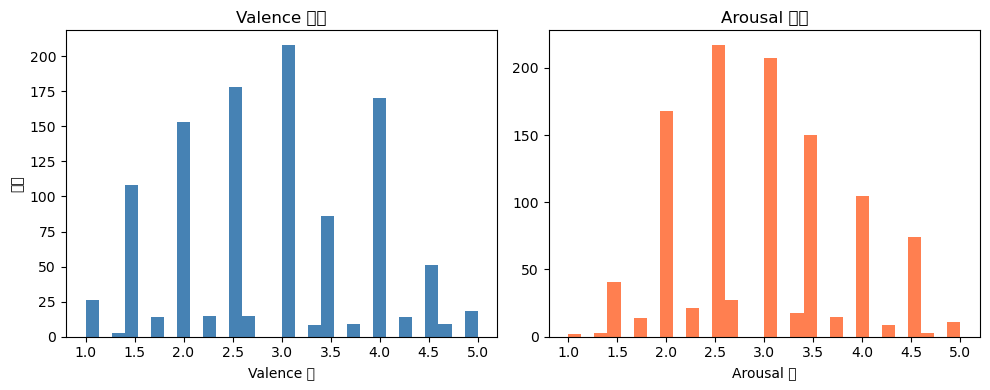

In [7]:
# Valence・Arousal の値の分布を確認する
# IEMOCAP のアノテーションは 1〜5 のスケールで付与されている
# 偏りが大きい場合は、後段の CCC 損失の学習が不安定になる可能性がある
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(data["va_labels"][:, 0], bins=30, color="steelblue")
axes[0].set_title("Valence 分布")
axes[0].set_xlabel("Valence 値")
axes[0].set_ylabel("頻度")

axes[1].hist(data["va_labels"][:, 1], bins=30, color="coral")
axes[1].set_title("Arousal 分布")
axes[1].set_xlabel("Arousal 値")

plt.tight_layout()
plt.show()

## 5. モデル構築・確認

`EmotionClassifier` の構造：

```
入力: (バッチ, フレーム数, 768)
  ↓
AttentionPooling  ─ アテンション重みで各フレームを重み付け平均 → (バッチ, 768)
  ↓
VADDecoder（FNN）─ Linear → LayerNorm → ReLU → Linear → Tanh → (バッチ, 3)
  ↓                   ※ Tanh により出力は -1〜1 に収まる
線形分類器       ─ Linear → (バッチ, 感情クラス数)
```

ダミー入力で forward を通し、出力の形状が正しいかを確認します。

In [8]:
# モデルを構築して GPU/CPU に配置する
# input_dim=768  : emotion2vec の特徴量次元
# hidden_dim=256 : VADDecoder 内の中間層の次元
# vad_dim=3      : V/A/D の3値を出力
# num_classes=4  : ang/hap/neu/sad の4クラス
model = EmotionClassifier(
    input_dim=768,
    hidden_dim=256,
    vad_dim=3,
    num_classes=len(LABEL_DICT),
).to(device)

print(model)
print()
total = sum(p.numel() for p in model.parameters())
print(f"総パラメータ数: {total:,}")

EmotionClassifier(
  (vad_decoder): VADDecoder(
    (pool): AttentionPooling(
      (score): Linear(in_features=768, out_features=1, bias=True)
    )
    (fnn): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=3, bias=True)
      (4): Tanh()
    )
  )
  (classifier): Linear(in_features=3, out_features=4, bias=True)
)

総パラメータ数: 198,932


In [9]:
# ダミー入力で forward の動作確認
# 実データがなくても形状・値の範囲が正しいかチェックできる
# padding_mask: True の位置がパディング（今は全フレームが有効なので全て False）
dummy_feats = torch.randn(4, 50, 768).to(device)   # (バッチ4, フレーム50, 特徴量768)
dummy_mask  = torch.zeros(4, 50, dtype=torch.bool).to(device)

vad_out, logits_out = model(dummy_feats, dummy_mask)
print("VAD出力の形状    :", vad_out.shape,    "  ← (バッチ, 3) [V, A, D]")
print("ロジットの形状   :", logits_out.shape, "  ← (バッチ, 感情クラス数)")
print("VAD値の範囲（Tanh）:", vad_out.min().item(), "〜", vad_out.max().item())

VAD出力の形状    : torch.Size([4, 3])   ← (バッチ, 3) [V, A, D]
ロジットの形状   : torch.Size([4, 4])   ← (バッチ, 感情クラス数)
VAD値の範囲（Tanh）: -0.7423948049545288 〜 0.32235023379325867


## 6. DataLoader 作成

5-fold Leave-One-Session-Out 交差検証のために、1セッションをテストセットとして分割します。

- `FOLD = 0` → Session1 をテストに使用（Session2〜5 が訓練・検証）
- 訓練データの 80% を train、20% を val に使用
- `eval_is_test=False` の場合、val はランダムサンプリングで作成

バッチ内で発話長が異なるため、短い発話はゼロパディングして揃え、  
パディング位置を示す `padding_mask` を一緒に返します。

In [10]:
# FOLD を 0〜4 で変えると、テストに使うセッションが変わる
# 0 = Session1, 1 = Session2, ..., 4 = Session5
FOLD = 0

# N_SAMPLES の累積和でセッション境界のインデックスを計算する
test_start = sum(N_SAMPLES[:FOLD])
test_end   = test_start + N_SAMPLES[FOLD]

train_loader, val_loader, test_loader = build_dataloaders(
    data, BATCH_SIZE, test_start, test_end, eval_is_test=False
)

print(f"Fold {FOLD + 1}: テスト範囲 [{test_start}, {test_end})")
print(f"  train バッチ数: {len(train_loader)}")
print(f"  val   バッチ数: {len(val_loader)}")
print(f"  test  バッチ数: {len(test_loader)}")

# バッチの中身を1つ確認してデータの形状が正しいかチェック
batch = next(iter(train_loader))
print()
print("バッチの中身:")
print("  feats の形状        :", batch["net_input"]["feats"].shape,    "  ← (バッチ, 最大フレーム数, 768)")
print("  padding_mask の形状 :", batch["net_input"]["padding_mask"].shape)
print("  labels の形状       :", batch["labels"].shape)
print("  va_labels の形状    :", batch["va_labels"].shape, "  ← (バッチ, 2) [V, A]")

ValueError: num_samples should be a positive integer value, but got num_samples=0

## 7. Stage 1 学習（VA-CCC 損失）

### 目的

VADDecoder に **Valence と Arousal を予測させる** ことで、感情の連続空間を学習させます。

### 損失関数：CCC（Concordance Correlation Coefficient）損失

CCC は予測値と正解値の一致度を -1〜1 で表す指標で、  
`CCC損失 = 1 - CCC` として最小化します（完全一致で 0）。

### 学習対象

- `model.vad_decoder` のパラメータのみを更新します
- `model.classifier`（分類器）は Stage 2 で学習するため、ここでは更新しません

学習が進むにつれて train/val の損失が下がっていけば正常です。

In [ ]:
STAGE1_EPOCHS = 30
STAGE1_LR     = 1e-3

# モデルをリセットして最初から学習（このセルを再実行すれば何度でもやり直せる）
model = EmotionClassifier(input_dim=768, hidden_dim=256, vad_dim=3, num_classes=len(LABEL_DICT)).to(device)

# Stage 1 では VADDecoder のみ学習する（分類器は含めない）
opt1 = torch.optim.Adam(model.vad_decoder.parameters(), lr=STAGE1_LR)

s1_train_losses = []
s1_val_losses   = []

for epoch in range(STAGE1_EPOCHS):
    # 1エポック学習（CCC 損失を逆伝播）
    train_loss = train_stage1(model, train_loader, opt1, device)
    # 検証セットで損失を計算（パラメータ更新なし）
    val_loss   = eval_stage1(model, val_loader, device)

    s1_train_losses.append(train_loss / len(train_loader))
    s1_val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | train loss: {s1_train_losses[-1]:.4f} | val loss: {s1_val_losses[-1]:.4f}")

: 

In [ ]:
# Stage 1 の損失曲線を可視化する
# train と val の差が大きければ過学習のサイン
plt.figure(figsize=(8, 4))
plt.plot(s1_train_losses, label="train loss")
plt.plot(s1_val_losses,   label="val loss")
plt.xlabel("Epoch")
plt.ylabel("CCC損失 (1 - CCC)")
plt.title("Stage 1: VA-CCC損失の推移")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"最終 val CCC損失: {s1_val_losses[-1]:.4f}  （0 に近いほど良い）")

# Stage 1 の重みを保存する（Stage 2 の初期値として使う）
torch.save(model.state_dict(), "stage1_best.pth")
print("stage1_best.pth を保存しました")

: 

## 8. Stage 2 学習（感情分類）

### 目的

Stage 1 で学習した VADDecoder を初期値として、**感情クラスの分類**を学習します。

### ハイパーパラメータ

| 変数 | 値 | 意味 |
|------|----|------|
| `STAGE2_EPOCHS` | 30 | 学習エポック数 |
| `STAGE2_LR_CLS` | 1e-3 | 線形分類器の学習率（大きめ：ランダム初期値から学習） |
| `STAGE2_LR_FNN` | 1e-4 | VADDecoder の学習率（小さめ：Stage 1 の重みを保護） |

### Stage 1 重みを引き継ぐ理由

Stage 2 をランダム初期値から始めると VAD 空間の意味的な構造が崩れやすいため、  
Stage 1 で学習した重みを初期値として使います（転移学習の考え方）。

### 2つの学習率（param_groups）の意図

PyTorch の `param_groups` を使うと、パラメータグループごとに異なる学習率を設定できます。

| グループ | 対象 | 学習率 | 理由 |
|---------|------|--------|------|
| グループ1 | `vad_decoder` | 1e-4（小） | Stage 1 で学習済み → 微調整。大きい lr にすると破壊的忘却が起きる |
| グループ2 | `classifier` | 1e-3（大） | ランダム初期値 → 素早く学習させる |

### `train_stage2` と `evaluate` の役割

- **`train_stage2`**: モデルを train モードにして1エポック全バッチを処理。forward → CrossEntropy 損失 → 逆伝播 → 重み更新。
- **`evaluate`**: eval モードで検証セット全件を推論し、WA・UA・F1 の3指標を返す。

### best_val_wa 保存ロジック

val WA が更新されたエポックだけ重みを保存します。  
最終エポックではなく「最も汎化性能が高かった時点」の重みをテスト評価に使うことで、  
過学習による性能低下を防ぎます（Early Stopping の考え方）。

In [ ]:
STAGE2_EPOCHS  = 30
STAGE2_LR_CLS  = 1e-3   # 線形分類器の学習率（ランダム初期値なので大きめ）
STAGE2_LR_FNN  = 1e-4   # VADDecoder の学習率（Stage1 の重みを壊さないよう小さめ）

# Stage 1 で学習した重みを読み込んで初期値にする
model.load_state_dict(torch.load("stage1_best.pth"))

# VADDecoder と分類器で異なる学習率を設定する
opt2 = torch.optim.Adam([
    {"params": model.vad_decoder.parameters(), "lr": STAGE2_LR_FNN},
    {"params": model.classifier.parameters(),  "lr": STAGE2_LR_CLS},
])
criterion = torch.nn.CrossEntropyLoss()

s2_train_losses = []
s2_val_wa_list  = []
best_val_wa = 0.0

for epoch in range(STAGE2_EPOCHS):
    train_loss = train_stage2(model, train_loader, opt2, criterion, device)
    val_wa, val_ua, val_f1 = evaluate(model, val_loader, device, num_classes=len(LABEL_DICT))

    s2_train_losses.append(train_loss / len(train_loader))
    s2_val_wa_list.append(val_wa)

    # val WA が更新されたとき最良モデルを保存する
    if val_wa > best_val_wa:
        best_val_wa = val_wa
        torch.save(model.state_dict(), "stage2_best.pth")

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | loss: {s2_train_losses[-1]:.4f} | val WA: {val_wa:.2f}%  UA: {val_ua:.2f}%  F1: {val_f1:.2f}%")


: 

### 学習曲線の確認

2つのグラフで Stage 2 の学習状況を確認します。

| グラフ | 縦軸 | 期待される動き |
|--------|------|----------------|
| 左: 訓練損失 | CrossEntropy 損失（小さいほど良） | 単調に下がること |
| 右: 検証 WA | Weighted Accuracy（高いほど良） | 上昇し続けること |

**過学習のサイン**: 訓練損失が下がり続けているのに検証 WA が横ばい・低下し始めた場合。  
対処法: `STAGE2_EPOCHS` を減らす、Dropout を追加するなど。

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(s2_train_losses, color="steelblue")
axes[0].set_title("Stage 2: 訓練損失の推移")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy 損失")
axes[0].grid(True)

axes[1].plot(s2_val_wa_list, color="coral")
axes[1].set_title("Stage 2: 検証 WA の推移")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("WA (%)")
axes[1].grid(True)

plt.tight_layout()
plt.show()


: 

## 9. テスト評価・結果まとめ

Stage 2 で最も val WA が高かったエポックの重み（`stage2_best.pth`）を使い、  
テストセット（未学習データ）で最終評価します。

### stage2_best.pth を使う理由

最終エポックの重みではなく、学習中で最も汎化性能が高かった時点の重みを使うことで  
過学習による性能低下を防ぎ、公正な評価ができます。

### 評価指標の意味と違い

| 指標 | 計算方法 | 特徴 |
|------|----------|------|
| **WA**（Weighted Accuracy） | 全正解数 / 全サンプル数 | クラス数が多い neu の影響を受けやすい |
| **UA**（Unweighted Accuracy） | 各クラスの正解率を単純平均 | クラス不均衡に強い。先行研究の主指標 |
| **F1**（Macro F1） | 各クラスの F1 を単純平均 | 少数クラスの誤分類に敏感で UA より厳しい |

> 参考: IEMOCAP の先行研究では WA/UA ともに 60〜70% 台が多い

### VAD 散布図の見方

テスト発話を VAD 空間（Valence / Arousal / Dominance）にプロットして、  
感情クラスの分離具合を確認します。

- `model.eval()` を呼ぶ理由: eval モードにしないと Dropout の影響で毎回結果が変わる
- `torch.no_grad()` を使う理由: 推論時は勾配追跡が不要なため、メモリと速度を節約できる

**感情心理学（Russell の円環モデル）に基づく期待パターン:**

| 感情 | Valence | Arousal | 散布図上の位置 |
|------|---------|---------|---------------|
| ang（怒り） | 低（不快） | 高（興奮） | 左上 |
| hap（喜び） | 高（快） | 高（興奮） | 右上 |
| sad（悲しみ） | 低（不快） | 低（静穏） | 左下 |
| neu（中立） | 中 | 低〜中 | 中央付近 |

クラスが空間上でよく分離していれば Stage 1 で意味のある VAD 表現が学習できた証拠です。

In [ ]:
# Stage 2 で最も val WA が高かったチェックポイントを読み込む
model.load_state_dict(torch.load("stage2_best.pth"))

# テストセット（このフォールドでは未使用のセッション）で最終評価
test_wa, test_ua, test_f1 = evaluate(model, test_loader, device, num_classes=len(LABEL_DICT))

print(f"=== Fold {FOLD + 1} テスト結果 ===")
print(f"  WA  : {test_wa:.2f}%  （全体の正解率）")
print(f"  UA  : {test_ua:.2f}%  （クラスを均等に重み付けした正解率）")
print(f"  F1  : {test_f1:.2f}%  （Macro F1 スコア）")


: 

In [ ]:
if "model" not in dir() or model is None:
    raise RuntimeError(
        "model が未定義です。セル '5. モデル構築' から順番に実行してください。"
    )

model.eval()
all_vad    = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        feats        = batch["net_input"]["feats"].to(device)
        padding_mask = batch["net_input"]["padding_mask"].to(device)
        labels       = batch["labels"]

        vad, _ = model(feats, padding_mask)
        all_vad.append(vad.cpu().numpy())
        all_labels.append(labels.numpy())

all_vad    = np.concatenate(all_vad,    axis=0)  # (N, 3): [Valence, Arousal, Dominance]
all_labels = np.concatenate(all_labels, axis=0)  # (N,)

label_names = list(LABEL_DICT.keys())
colors      = ["red", "green", "blue", "orange"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [("Valence", "Arousal", 0, 1), ("Valence", "Dominance", 0, 2), ("Arousal", "Dominance", 1, 2)]

for ax, (xlabel, ylabel, xi, yi) in zip(axes, pairs):
    for cls_idx, (name, color) in enumerate(zip(label_names, colors)):
        mask = all_labels == cls_idx
        ax.scatter(all_vad[mask, xi], all_vad[mask, yi], label=name, color=color, alpha=0.4, s=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{xlabel} vs {ylabel}")
    ax.legend(markerscale=2)
    ax.grid(True)

plt.suptitle("テストセット: VAD空間での感情分布", y=1.02)
plt.tight_layout()
plt.show()


: 